In [4]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve


In [18]:
# 1 = fraud, 0 = legitimate
y_true = [1, 0, 1, 0, 1, 0, 0, 1, 0, 0]

# Model-predicted fraud probabilities
y_score = [
    0.95, 0.80, 0.75, 0.60, 0.55,
    0.40, 0.30, 0.25, 0.10, 0.05
]

precision, recall, thresholds = precision_recall_curve(
    y_true,
    y_score
)


print(f'precision {precision} \nrecall {recall} and\nthreshold {thresholds}')
# precision and recall have one extra final value
precision_values = precision[:-1] # deleting last value from the list
recall_values = recall[:-1]# deleting last value from the list
# Threshold that we want to examine
selected_threshold = 0.50


precision [0.4        0.44444444 0.5        0.42857143 0.5        0.6
 0.5        0.66666667 0.5        1.         1.        ] 
recall [1.   1.   1.   0.75 0.75 0.75 0.5  0.5  0.25 0.25 0.  ] and
threshold [0.05 0.1  0.25 0.3  0.4  0.55 0.6  0.75 0.8  0.95]


In [14]:
# Find the closest available threshold
index = abs(thresholds - selected_threshold).argmin()

selected_threshold = thresholds[index]
selected_precision = precision_values[index]
selected_recall = recall_values[index]


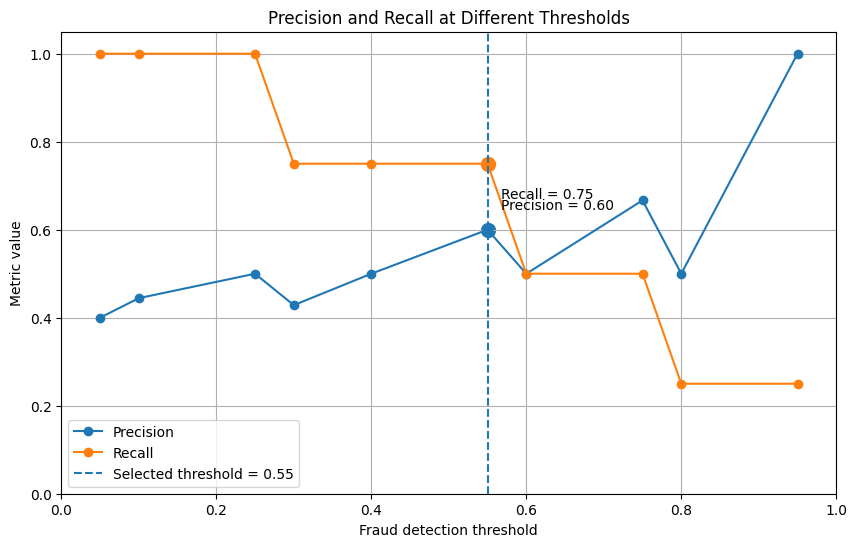

In [17]:



plt.figure(figsize=(10, 6))

# Two lines
plt.plot(
    thresholds,
    precision_values,
    marker="o",
    label="Precision"
)

plt.plot(
    thresholds,
    recall_values,
    marker="o",
    label="Recall"
)

# Vertical line at selected threshold
plt.axvline(
    x=selected_threshold,
    linestyle="--",
    label=f"Selected threshold = {selected_threshold:.2f}"
)

# Mark the intersection with precision
plt.scatter(
    selected_threshold,
    selected_precision,
    s=100
)

# Mark the intersection with recall
plt.scatter(
    selected_threshold,
    selected_recall,
    s=100
)

# Add value labels
plt.annotate(
    f"Precision = {selected_precision:.2f}",
    xy=(selected_threshold, selected_precision),
    xytext=(10, 15),
    textcoords="offset points"
)

plt.annotate(
    f"Recall = {selected_recall:.2f}",
    xy=(selected_threshold, selected_recall),
    xytext=(10, -25),
    textcoords="offset points"
)

plt.xlabel("Fraud detection threshold")
plt.ylabel("Metric value")
plt.title("Precision and Recall at Different Thresholds")

plt.xlim(0, 1)
plt.ylim(0, 1.05)

plt.grid()
plt.legend()
plt.show()